## Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("Expectation Decider Data.csv")
data

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,73,Yes,72,Pass
1,18,70,Yes,100,Fail
2,14,57,Yes,57,Fail
3,11,74,Yes,68,Pass
4,10,78,Yes,75,Pass
...,...,...,...,...,...
195,8,55,Yes,42,Fail
196,8,59,No,62,Fail
197,12,58,Yes,59,Pass
198,12,70,Yes,73,Fail


## 1. Understanding the Basics

## What is Probability?

**Answer:** Probability kisi event ke hone ke chance ko measure karti hai.

**Formula:**

$$
P(E)=\frac{\text{Number of Favorable Outcomes}}
{\text{Total Outcomes}}
$$

##  Examples

**Event 1:** Student passes final exam.

In [15]:
#Probablity event examples from dataset using manual count and length
Study_count = (data['study_hours'] >10).sum()
attendance_count = (data['attendance'] > 80).sum()
pass_count = (data['final_exam_pass'] == 'Pass').sum()

total_students = len(data)

prob_study = Study_count / total_students
prob_attendance = attendance_count / total_students
prob_pass = pass_count / total_students

print("Students studying > 10 hrs/week:", Study_count)
print("Students attendance  > 80%:", attendance_count)
print("Students who pass:", pass_count)
print()
print("Probability of Student study >10hrs/week:", prob_study)
print("Probability of student Attendance > 80%", prob_attendance)
print("Probability of student passing Eaxm:", prob_pass)

Students studying > 10 hrs/week: 108
Students attendance  > 80%: 87
Students who pass: 121

Probability of Student study >10hrs/week: 0.54
Probability of student Attendance > 80% 0.435
Probability of student passing Eaxm: 0.605


## 2. Types of Events

## Empirical Probability

**Answer:** Dataset ke actual data se calculate hoti hai.

**Formula:**  
$$
P(E)=\frac{\text{Favorable Outcomes}}
{\text{Total Possible Outcomes}}
$$

## Example

In [16]:
P_pass = (data['final_exam_pass'] == 'Pass').mean()

print("Empirical Probability of Passing =", P_pass)

Empirical Probability of Passing = 0.605


## Theoretical Probability

**Answer:**  Formula based probability

**Formula:**  
$$
P(E)=\frac{\text{Favorable Outcomes}}
{\text{Total Possible Outcomes}}
$$

## Example


In [17]:
P_head = 1/2

print("Theoretical Probability of Head =", P_head)

Theoretical Probability of Head = 0.5


## 3. Random Variable & Probability Distribution

**Definition of Random Variable:**
Let \(x\) be the random Variable representing the **number of Students passing the final exams** out of 3 randomly selected students.
Since each students either **Passes** or **Fails**, \(x\) can take values:
$$x = 0,1,2,3$$

**Probability Distrbution:**
We assume the probability of passing is the empirical probability from the dataset:
$$P(\text{pass}) =P,\quad P(\text{fail}) = 1-p$$

The distribution of \(x\) follows a **Binomial Distribution**:
$$P(x = k) = \binom{3}{k} \cdot p^k \cdot (1-p)^{3-k}, \quad \text{Where} K = 0,1,2,3$$

**Mean and Variance:**
$$\mu = n \cdot p$$

$$\sigma^2 = n \cdot p \cdot (1-p)$$

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import binom

# Empirical Probability of Pass
empirical_pass_prob = len(data[data['final_exam_pass'] == 'Pass']) / len(data)

# Number of trials
n_trials = 3

# Possible values of X
x = np.arange(0, n_trials + 1)

# Binomial PMF
pmf = binom.pmf(x, n_trials, empirical_pass_prob)

# Probability Distribution Table
distribution_table = pd.DataFrame({
    'X (passes)': x,
    'P(X)': pmf
})

print("Probability Distribution Table:")
print(distribution_table)

# Mean
mean = n_trials * empirical_pass_prob

# Variance
variance = n_trials * empirical_pass_prob * (1 - empirical_pass_prob)

print("\nMean =", mean)
print("Variance =", variance)

Probability Distribution Table:
   X (passes)      P(X)
0           0  0.061630
1           1  0.283185
2           2  0.433740
3           3  0.221445

Mean = 1.815
Variance = 0.716925


## 4. Venn Diagram Probability

We want to visualize the relationship between two group of students:

- **Set A**: Students who study more than 10 hr/week.
- **Set B**: Students who attent more than 80% of classes.
- **Overlap (A ∩ B)**: STudents who satisfy both conditions.

This can be represented using a venn diagram.

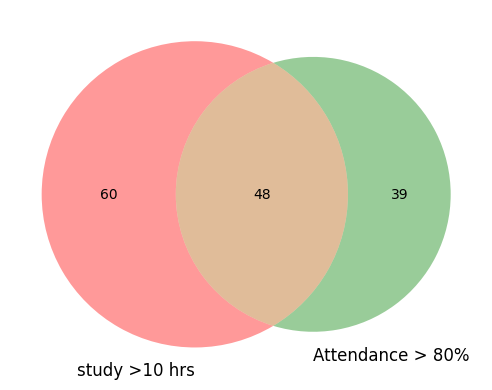

In [19]:
from matplotlib_venn import venn2

A = set(data[data['study_hours'] >10].index)
B = set(data[data['attendance'] >80].index)

venn2([A,B], set_labels=('study >10 hrs', 'Attendance > 80%'))
plt.show()

## 5.Contingency Table & Probability

We need to:

1. Create a countingency table for **Group Discussion (Yes/No)** vs **Final Exam Pass (Pass/Fail)**.
2. Calculate:
    - **Joint Probability**: P(Pass)
    - **Conditional Probability**: p(Pass | Grop Discussion = yes)
    

In [5]:
yes_and_pass_count = len(data[(data['group_discussion'] == 'Yes') & (data['final_exam_pass'] == 'pass')])
yes_count = len(data[data['group_discussion'] == 'Yes'])
total_students = len(data)

joint_probability = yes_and_pass_count / total_students
marginal_probability_yes = yes_count / total_students
conditional_probability = joint_probability / marginal_probability_yes

print("Joint Count (Yes & Pass):", yes_and_pass_count)
print("Marginal Count (Yes):", yes_count)
print("Joint Probability p(Yes ^ pass):", joint_probability)
print("Marginal Probability P(Yes):", marginal_probability_yes)
print("Counditional Probability P(pass | Yes):", conditional_probability)

Joint Count (Yes & Pass): 0
Marginal Count (Yes): 118
Joint Probability p(Yes ^ pass): 0.0
Marginal Probability P(Yes): 0.59
Counditional Probability P(pass | Yes): 0.0


## 6. Understanding Relationships

## Step 1: Interpret Conditional Probability

Conditional Probability formula:
$$P(A|B) = \frac{P(A \cap B)}{p(B)}$$

**Plain Languge Intuition:**
- It tells us the chance of event **A** happening **given** That event **B** has already occurred.
- Example: "Probability of passing the eaxm given the student participated in group discussion.""

In [7]:
# Students who participated in Group Discussion and Passed
yes_and_pass_count = len(
    data[
        (data['group_discussion'] == 'Yes') &
        (data['final_exam_pass'] == 'Pass')
    ]
)

# Total students who participated in Group Discussion
yes_count = len(
    data[data['group_discussion'] == 'Yes']
)

# Conditional Probability
conditional_probability = yes_and_pass_count / yes_count

print("Conditional Probability P(Pass | GD='Yes') =", conditional_probability)

Conditional Probability P(Pass | GD='Yes') = 0.635593220338983


## Step 2: Independence, Dependence, or Mutual Exclusivity

- **Independence Event:**
    Two events are independent if the probability of one does not change when the other occurs.
    Mathematically:

    $$
    P(A \cap B) = p(A) \cdot p(b)
    $$
    
- **Dependent Event:**
    If participation in group discssion changes the probability of passing, then they are dependent.

- **Mutually Exclusive Events:**
    Two events connot happen together,
    Example: "Pass and "Fail" are mutally exclusive.
    But "Group Discussion Yes" and "Pass can occur together, so they are **not** mutaully exclusive

In [4]:
total = len(data)

p_yes = len(data[data['group_discussion'] == 'Yes' ]) / total
P_pass = len(data[data['final_exam_pass'] == 'Pass']) / total

p_yes_and_pass = len(data[(data['group_discussion'] == 'Yes')&
                          (data['final_exam_pass'] == 'Pass')]) / total

print("P(Yes):", p_yes)
print("P(Pass):", P_pass)
print("P(Yes & Pass):", p_yes_and_pass)

if p_yes_and_pass == p_yes * P_pass:
    print("Event are Independent")
else:
    print("Event are Dependent")

P(Yes): 0.59
P(Pass): 0.605
P(Yes & Pass): 0.375
Event are Dependent


## 7. Bayes Theorem Application

We are given:
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- p(High Attendance) = 0.60

We want: P(Pass | High Attendance)

Bayes Theorem:
$$P(Pass | High) = \frac{P(High | Pass) \cdot P(Pass)}{P(High)}$$

In [6]:
P_high_given_pass = 0.70
p_high_given_fail = 0.40
p_high = 0.60

P_pass = 0.20 / 0.30
P_fail = 1 - P_pass

P_pass_given_high =(P_high_given_pass * P_pass) / p_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)

P(Pass): 0.6666666666666667
P(Fail): 0.33333333333333326
P(Pass | High Attendance): 0.7777777777777778


## Final Conclusion 

From the analysis:

- **Study hours, attendance, and group discussion participation** all play a significant role in determining exam success.
- The **contingency table** showed that students who joined group discussions had a higher probability of passing compared to those who did not
- The **conditional probability** confirmed that participation increases the likehood of success, meaning these events are **dependent** rather than independent.
- Using **Baayes Theores**, We found that students with high attendance have a much greater chance of passing (~78%), Showing attendance is a strong predictor of exam performance.

## Summery
Overall, the factors that most affect the probability of passing are:
1. **High attendance (>80%)**
2. **Active participation in group discussions**
3. **Consistent study hours and prior test performance**

Thus, encouraging students to maintain strong attendance and engage in collaborattive learning activities significantly imporves their chances of success in cometitive exams